# NeuroSegment-BraTS: Resultados e Explicabilidade

**Notebook 5:** Resultados e Explicabilidade através de XAI



## 1. Configuração e Carga dos Modelos

**O que fazer aqui:**
Nesta seção, preparamos o ambiente para lidar com volumes 3D pesados em um ambiente de hardware limitado (GPU < 4GB).

**Pontos de Atenção:**

- Gestão de VRAM: É mandatório rodar a função `reset_gpu_context()` ao trocar de arquitetura (ex: de U-Net para Swin). Isso limpa o cache do `CUDA` e evita o erro `OutOfMemory`.
- Arquitetura Dinâmica: Verifique se o init_filters condiz com o peso treinado (ex: 32 filtros para modelos otimizados via Optuna).
- Monkey Patching: Aplicamos correções em tempo real nas camadas inplace do SegResNet para permitir que os gradientes do `Grad-CAM` e `SHAP` fluam sem erros.

In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
%reload_ext autoreload

import os
import gc
import sys
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(".."))

from torch import amp

from src.data_utils import get_val_transforms, get_sample_data
from monai.visualize import GradCAM
from monai.networks.blocks import ResBlock
from monai.networks.nets import SwinUNETR, UNet, SegResNet

# Carregar transformações
transforms = get_val_transforms()

# Preparar uma única amostra para XAI
data_dir = '../data/raw/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'

patient_id = "BraTS20_Training_001"
sample = get_sample_data(data_dir, patient_id)
processed_sample = transforms(sample)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# O BraTS usa 4 modalidades (FLAIR, T1, T1ce, T2) como canais de entrada
input_tensor = processed_sample["image"].unsqueeze(0).to(device)
input_tensor.requires_grad = True
print(f"Shape para XAI: {input_tensor.shape}")


/home/leovianaf/projetos/NeuroSegment-BraTS-MONAI/venv/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Shape para XAI: torch.Size([1, 4, 64, 64, 64])


In [18]:
def reset_gpu_context(vars_to_delete=None):
  """
  Libera memória VRAM e RAM deletando objetos e limpando o cache do CUDA.

  Args:
      vars_to_delete (list): Lista de strings com os nomes das variáveis
                              (ex: ['model_unet', 'cam', 'result', 'explainer'])
  """
  print("--- Iniciando limpeza de memória ---")

  # Deletar variáveis específicas do escopo global
  if vars_to_delete:
    for var_name in vars_to_delete:
      if var_name in globals():
        print(f"Deletando variável: {var_name}")
        del globals()[var_name]
      elif var_name in locals():
        print(f"Deletando variável local: {var_name}")
        del locals()[var_name]

  # Forçar o Garbage Collector do Python
  gc.collect()

  # Limpar cache do PyTorch
  if torch.cuda.is_available():
    # Sincroniza para garantir que todas as operações terminaram
    torch.cuda.synchronize()
    torch.cuda.empty_cache()

    # Estatísticas finais
    allocated = torch.cuda.memory_allocated() / 1024**2
    reserved = torch.cuda.memory_reserved() / 1024**2
    print(f"VRAM Alocada: {allocated:.2f}MB")
    print(f"VRAM Reservada: {reserved:.2f}MB")

  print("--- Ambiente pronto para nova amostragem ---")

# Configuração sugerida para evitar fragmentação em GPUs pequenas
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [19]:
def safe_forward(self, x):
    identity = x
    x = self.norm1(x)
    x = self.act(x)
    x = self.conv1(x)
    x = self.norm2(x)
    x = self.act(x)
    x = self.conv2(x)
    x = x + identity
    return x

ResBlock.forward = safe_forward
print(">> Patch aplicado: ResBlock agora é compatível com Grad-CAM.")

>> Patch aplicado: ResBlock agora é compatível com Grad-CAM.


## 2. Explicabilidade por técnicas em ambos os modelos do Experimento

### 2.1 Grad-CAM

**O que é:** O `Grad-CAM` *(Gradient-weighted Class Activation Mapping)* utiliza os gradientes da última camada convolucional para produzir um mapa de ativação que destaca as regiões importantes para a predição.

**Insumos e Insights:**

- Validação Biológica: O objetivo aqui é confirmar se o modelo está "olhando" para o tumor ou para ruídos no fundo da imagem. Se o calor (vermelho) estiver sobre a massa tumoral, o modelo é confiável.
- Foco Regional: Diferente de outras técnicas, o `Grad-CAM` nos dá uma visão "macro" e esfumaçada, excelente para apresentações clínicas, pois se assemelha à forma como radiologistas circundam áreas de interesse.
- Sensibilidade de Classe: Podemos alternar o `class_idx` para ver se o modelo foca em áreas diferentes para o **Edema (ED)** vs. **Tumor Ativo (ET)**.

#### 2.1.1 U-Net 3D

In [25]:
model_unet = UNet(
  spatial_dims=3,
  in_channels=4,
  out_channels=4,
  channels=(16, 32, 64, 128, 256),
  strides=(2, 2, 2, 2),
  num_res_units=2,
).to(device)

model_opt = "v0"
model_unet.load_state_dict(torch.load(f"../models/best_metric_model_Unet_3D_{model_opt}.pth"))
model_unet.eval()

UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(4, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(4, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Se

In [26]:
# Pegando penultima camada
target_layer_unet = "model.2.1.conv.unit0.conv"

# Instanciar o Grad-CAM
cam = GradCAM(nn_module=model_unet, target_layers=[target_layer_unet])

# Gerar o heatmap para uma classe específica (ex: class_idx=3 para Enhancing Tumor)
# input_tensor deve ter o shape (1, 4, D, H, W)
with amp.autocast(device_type="cuda"):  # Use autocast para acelerar a inferência em GPU
  result = cam(x=input_tensor, class_idx=3)

# Processamento do Heatmap
slice_idx = input_tensor.shape[2] // 2
heatmap_slice = result[0, 0, slice_idx, :, :].cpu().numpy()

# Normalização do heatmap para visualização
heatmap_norm = (heatmap_slice - heatmap_slice.min()) / (heatmap_slice.max() - heatmap_slice.min() + 1e-8)
heatmap_norm[heatmap_norm < 0.6] = 0  # Threshold agressivo para limpar o parênquima saudável

print(f">> Heatmap gerado com sucesso. Shape: {heatmap_norm.shape}")

>> Heatmap gerado com sucesso. Shape: (128, 128)


>> Nenhum tumor (ET) detectado no slice 64


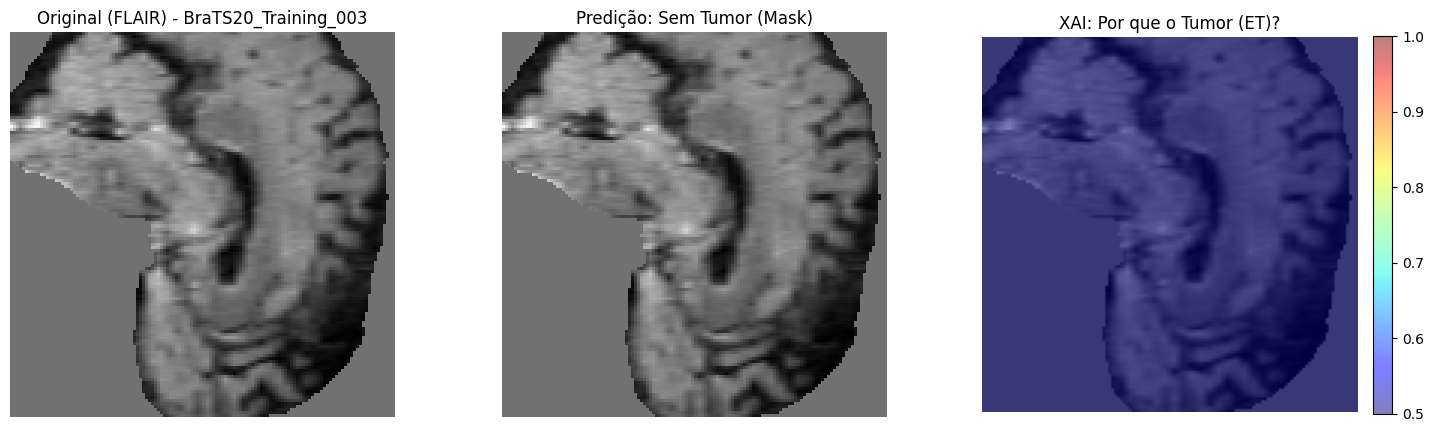

In [27]:
# Fazemos a inferência simples para obter a predição
with torch.no_grad():
    # Usamos o modelo original para pegar todas as classes
    val_outputs = model_unet(input_tensor)

    # Aplicamos Softmax para transformar em probabilidades e Argmax para a classe final
    val_preds = torch.softmax(val_outputs, dim=1).argmax(dim=1)

# Selecionamos o mesmo slice que usamos no XAI
pred_slice = val_preds[0, slice_idx, :, :].cpu().numpy()

has_tumor = np.any(pred_slice == 3)
# Criar a mensagem personalizada
if has_tumor:
    status_msg = f"Tumor (ET) ENCONTRADO no slice {slice_idx}"
else:
    status_msg = f"Nenhum tumor (ET) detectado no slice {slice_idx}"

print(f">> {status_msg}")

# Pegar a imagem original (Canal 0 - FLAIR) no mesmo slice
# A normalização utiliza a fórmula: (x - min) / (max - min + epsilon)
img_slice = input_tensor[0, 0, slice_idx, :, :].detach().cpu().numpy()
img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)

plt.figure(figsize=(18, 5))

# Imagem Original
plt.subplot(1, 3, 1)
plt.title(f"Original (FLAIR) - {patient_id}")
plt.imshow(img_slice, cmap="gray")
plt.axis("off")

# Predição do Modelo (Máscara)
plt.subplot(1, 3, 2)
plt.title(f"Predição: {'Tumor' if has_tumor else 'Sem Tumor'} (Mask)")
plt.imshow(img_slice, cmap="gray") # Fundo
masked_pred = np.ma.masked_where(pred_slice == 0, pred_slice)
plt.imshow(masked_pred, cmap="autumn", alpha=0.6)
plt.axis("off")

# Grad-CAM (Explicabilidade)
plt.subplot(1, 3, 3)
plt.title("XAI: Por que o Tumor (ET)?")
plt.imshow(img_slice, cmap="gray")
plt.imshow(heatmap_norm, cmap="jet", alpha=0.5, vmin=0.5, vmax=1.0)
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis("off")

# Salvar a figura completa como PNG
file_name = f"../reports/gradcam_unet3d_{model_opt}_{patient_id}.png"
plt.savefig(file_name, bbox_inches='tight', dpi=300)
plt.show()
plt.close()

In [28]:
reset_gpu_context(['model_unet', 'cam', 'result', 'heatmap_norm'])

--- Iniciando limpeza de memória ---
Deletando variável: model_unet
Deletando variável: cam
Deletando variável: result
Deletando variável: heatmap_norm
VRAM Alocada: 831.30MB
VRAM Reservada: 1058.00MB
--- Ambiente pronto para nova amostragem ---


#### 2.1.2 SegResNet

In [5]:
model_opt = "v0"

init_filters = 16
if model_opt == "v0":
  init_filters = 16
elif model_opt == "v1":
  init_filters = 32

## Arquitetura Adaptada para versão original e otimizada
model_segresnet = SegResNet(
  in_channels=4,
  out_channels=4,
  init_filters=init_filters,
  dropout_prob=0.2,
).to(device)

model_segresnet.load_state_dict(torch.load(f"../models/best_metric_model_segresnet_{model_opt}.pth"))
model_segresnet.eval()

print(model_segresnet)

SegResNet(
  (act_mod): ReLU(inplace=True)
  (convInit): Convolution(
    (conv): Conv3d(4, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
  )
  (down_layers): ModuleList(
    (0): Sequential(
      (0): Identity()
      (1): ResBlock(
        (norm1): GroupNorm(8, 16, eps=1e-05, affine=True)
        (norm2): GroupNorm(8, 16, eps=1e-05, affine=True)
        (act): ReLU(inplace=True)
        (conv1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        )
        (conv2): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        )
      )
    )
    (1): Sequential(
      (0): Convolution(
        (conv): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
      )
      (1): ResBlock(
        (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
        (norm2): GroupNorm(8, 32, eps=1e-05, a

In [6]:
# O SegResNet tem camadas com ReLU inplace, o que pode causar problemas de gradiente durante o Grad-CAM.
for m in model_segresnet.modules():
  if hasattr(m, 'inplace'):
    m.inplace = False

# Pegando penultima camada
target_layer_segresnet = "up_layers.2.0.conv2.conv"

# Instanciar o Grad-CAM
cam = GradCAM(nn_module=model_segresnet, target_layers=[target_layer_segresnet])

# Gerar o heatmap para uma classe específica (ex: class_idx=3 para Enhancing Tumor)
# input_tensor deve ter o shape (1, 4, D, H, W)
with amp.autocast(device_type="cuda"):  # Use autocast para acelerar a inferência em GPU
  result = cam(x=input_tensor, class_idx=3)

# Processamento do Heatmap
slice_idx = input_tensor.shape[2] // 2
heatmap_slice = result[0, 0, slice_idx, :, :].cpu().numpy()

# Normalização do heatmap para visualização
heatmap_norm = (heatmap_slice - heatmap_slice.min()) / (heatmap_slice.max() - heatmap_slice.min() + 1e-8)
heatmap_norm[heatmap_norm < 0.6] = 0  # Threshold agressivo para limpar o parênquima saudável

print(f">> Heatmap gerado com sucesso. Shape: {heatmap_norm.shape}")

>> Heatmap gerado com sucesso. Shape: (128, 128)


>> Tumor (ET) ENCONTRADO no slice 64


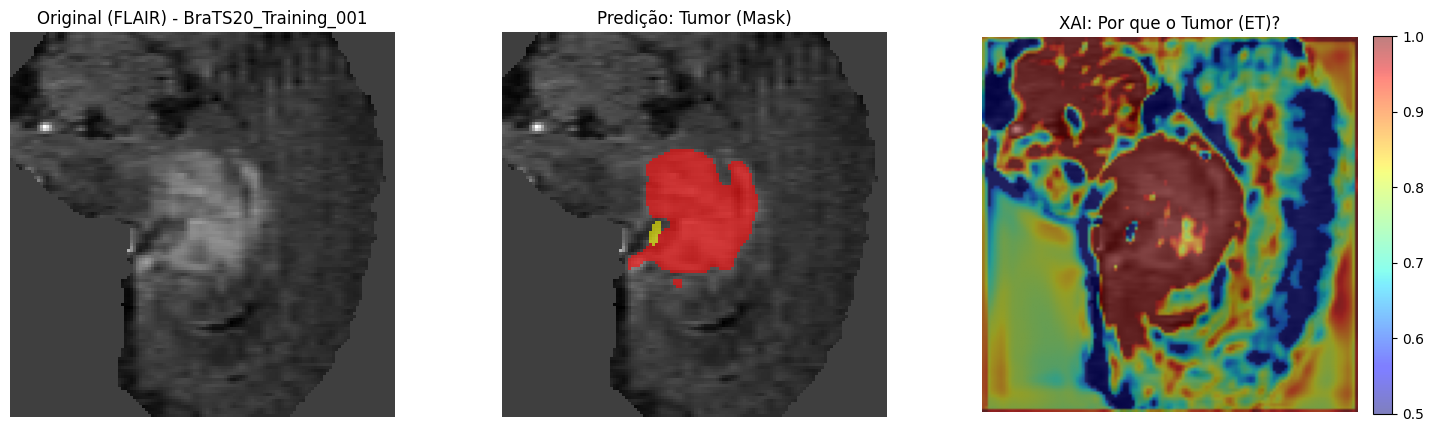

In [7]:
# Fazemos a inferência simples para obter a predição
with torch.no_grad():
    # Usamos o modelo original para pegar todas as classes
    val_outputs = model_segresnet(input_tensor)

    # Aplicamos Softmax para transformar em probabilidades e Argmax para a classe final
    val_preds = torch.softmax(val_outputs, dim=1).argmax(dim=1)

# Selecionamos o mesmo slice que usamos no XAI
pred_slice = val_preds[0, slice_idx, :, :].cpu().numpy()

has_tumor = np.any(pred_slice == 3)
# Criar a mensagem personalizada
if has_tumor:
    status_msg = f"Tumor (ET) ENCONTRADO no slice {slice_idx}"
else:
    status_msg = f"Nenhum tumor (ET) detectado no slice {slice_idx}"

print(f">> {status_msg}")

# Pegar a imagem original (Canal 0 - FLAIR) no mesmo slice
# A normalização utiliza a fórmula: (x - min) / (max - min + epsilon)
img_slice = input_tensor[0, 0, slice_idx, :, :].detach().cpu().numpy()
img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)

plt.figure(figsize=(18, 5))

# Imagem Original
plt.subplot(1, 3, 1)
plt.title(f"Original (FLAIR) - {patient_id}")
plt.imshow(img_slice, cmap="gray")
plt.axis("off")

# Predição do Modelo (Máscara)
plt.subplot(1, 3, 2)
plt.title(f"Predição: {'Tumor' if has_tumor else 'Sem Tumor'} (Mask)")
plt.imshow(img_slice, cmap="gray") # Fundo
masked_pred = np.ma.masked_where(pred_slice == 0, pred_slice)
plt.imshow(masked_pred, cmap="autumn", alpha=0.6)
plt.axis("off")

# Grad-CAM (Explicabilidade)
plt.subplot(1, 3, 3)
plt.title("XAI: Por que o Tumor (ET)?")
plt.imshow(img_slice, cmap="gray")
plt.imshow(heatmap_norm, cmap="jet", alpha=0.5, vmin=0.5, vmax=1.0)
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis("off")

# Salvar a figura completa como PNG
file_name = f"../reports/gradcam_segresnet_{model_opt}_{patient_id}.png"
plt.savefig(file_name, bbox_inches='tight', dpi=300)
plt.show()
plt.close()

In [8]:
reset_gpu_context(['model_segresnet', 'cam', 'result', 'heatmap_norm'])

--- Iniciando limpeza de memória ---
Deletando variável: model_segresnet
Deletando variável: cam
Deletando variável: result
Deletando variável: heatmap_norm
VRAM Alocada: 358.09MB
VRAM Reservada: 690.00MB
--- Ambiente pronto para nova amostragem ---


#### 2.1.3 Swin UNETR

In [ ]:
model_swin = SwinUNETR(
  in_channels=4,
  out_channels=4,
  feature_size=12,
  use_checkpoint=True,
).to(device)

model_opt = "v0"
model_swin.load_state_dict(torch.load(f"../models/best_metric_model_swin_unetr_{model_opt}.pth"))
model_swin.eval()

print(model_swin)

In [ ]:
# Pegando penultima camada
target_layer_swin = "out.conv.conv"

# Instanciar o Grad-CAM
cam = GradCAM(nn_module=model_swin, target_layers=[target_layer_swin])

# Gerar o heatmap para uma classe específica (ex: class_idx=3 para Enhancing Tumor)
# input_tensor deve ter o shape (1, 4, D, H, W)
with amp.autocast(device_type="cuda"):  # Use autocast para acelerar a inferência em GPU
  result = cam(x=input_tensor, class_idx=3)

# Processamento do Heatmap
slice_idx = input_tensor.shape[2] // 2
heatmap_slice = result[0, 0, slice_idx, :, :].cpu().numpy()

# Normalização do heatmap para visualização
heatmap_norm = (heatmap_slice - heatmap_slice.min()) / (heatmap_slice.max() - heatmap_slice.min() + 1e-8)
heatmap_norm[heatmap_norm < 0.6] = 0  # Threshold agressivo para limpar o parênquima saudável

print(f">> Heatmap gerado com sucesso. Shape: {heatmap_norm.shape}")

In [ ]:
# Pegar a imagem original (Canal 0 - FLAIR) no mesmo slice
img_slice = input_tensor[0, 0, slice_idx, :, :].detach().cpu().numpy()
img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Imagem Original (FLAIR)")
plt.imshow(img_slice, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Grad-CAM Overlay (Classe 3)")
plt.imshow(img_slice, cmap="gray")
plt.imshow(heatmap_norm, cmap="jet", alpha=0.5, vmin=0.5, vmax=1.0)
plt.colorbar()
plt.axis("off")

# Salvar o gráfico como PNG
file_name = f"../reports/swin_unetr_result_{model_opt}_{patient_id}.png"
plt.savefig(file_name, bbox_inches='tight', dpi=300)
print(f">> Gráfico salvo como: {file_name}")

plt.show()
plt.close()

In [8]:
reset_gpu_context(['model_swin', 'cam', 'result', 'heatmap_norm'])

--- Iniciando limpeza de memória ---
Deletando variável: cam
VRAM Alocada: 3446.54MB
VRAM Reservada: 3494.00MB
--- Ambiente pronto para nova amostragem ---


### 2.2 SHAP

**O que é:** O `SHAP` *(SHapley Additive exPlanations)* utiliza teoria dos jogos para atribuir a cada voxel da entrada um valor de contribuição para o resultado final. Usamos o `GradientExplainer` para integrar os gradientes ao longo de um caminho entre a imagem e um background de zeros.

**Insumos e Insights:**

- Análise Multimodal: O maior insumo aqui é entender qual sequência (FLAIR, T1, T1ce ou T2) foi decisiva. Por exemplo, esperamos que o T1ce (canal 2) tenha a maior contribuição positiva (pontos vermelhos) para a Classe 3 (Enhancing Tumor).
- Decisão por Voxel: Ao contrário do `Grad-CAM`, o `SHAP` é granular. Ele revela se pequenos detalhes de contraste ou bordas foram os "gatilhos" para a segmentação.
- Verificação de Viés: Se o `SHAP` mostrar muita importância em áreas de tecido saudável (azuis ou vermelhos fora do tumor), isso indica que o modelo pode estar superestimando certas modalidades ou sofrendo com ruído de amostragem (nsamples baixo).

In [20]:
# Para volumes 3D, o GradientExplainer é o mais indicado para PyTorch
background = torch.zeros_like(input_tensor).to(device)

In [21]:
class SegmentationModelWrapper(torch.nn.Module):
  def __init__(self, model, class_idx):
    super().__init__()
    self.model = model
    self.class_idx = class_idx

  def forward(self, x):
    logits = self.model(x)
    # Seleciona a classe desejada e soma todos os voxels
    # para criar um "Score Total" (Escalar)
    return logits[:, self.class_idx].sum(dim=(1, 2, 3)).unsqueeze(1)

#### 2.2.1 U-Net 3D

In [26]:
model_unet = UNet(
  spatial_dims=3,
  in_channels=4,
  out_channels=4,
  channels=(16, 32, 64, 128, 256),
  strides=(2, 2, 2, 2),
  num_res_units=2,
).to(device)

model_opt = "v1"
model_unet.load_state_dict(torch.load(f"../models/best_metric_model_Unet_3D_{model_opt}.pth"))
model_unet.eval()

UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(4, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(4, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Se

In [27]:
# Queremos explicar a Classe 3 (Enhancing Tumor)
wrapped_model = SegmentationModelWrapper(model_unet, class_idx=3).to(device)

explainer_unet = shap.GradientExplainer(wrapped_model, background)

shap_values_unet = explainer_unet.shap_values(input_tensor, nsamples=50)

>> SHAP Overlay salvo em: ../reports/shap/shap_overlay_unet3d_v1_BraTS20_Training_003.png


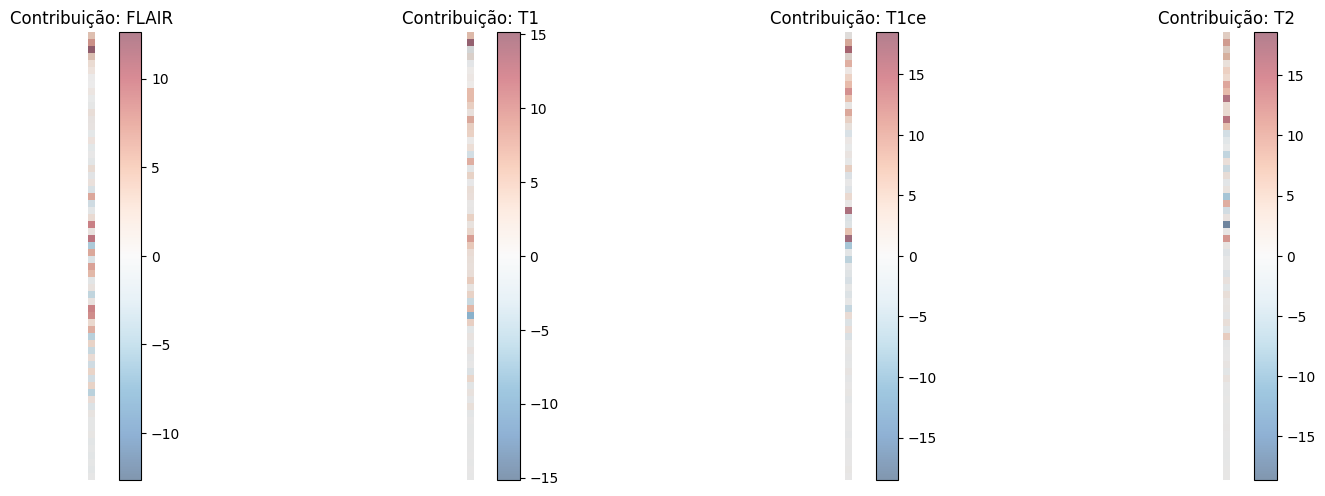

In [28]:
slice_idx = input_tensor.shape[2] // 2
modalidades = ["FLAIR", "T1", "T1ce", "T2"]

img_slice = input_tensor[0, 0, slice_idx, :, :].detach().cpu().numpy()
img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Como usamos o wrapper para a Classe 3, o resultado está no índice 0
shap_data = shap_values_unet[0]

for i, mod in enumerate(modalidades):
    # s shape: (D, H, W) -> Pegamos o slice_idx
    s = shap_data[0, i, slice_idx, :, :]

    # Plotar a imagem original de fundo (com transparência)
    axes[i].imshow(img_slice, cmap="gray", alpha=0.3)

    # Plotar o SHAP (RdBu_r: Vermelho é positivo, Azul é negativo)
    vmax = np.percentile(np.abs(s), 99.9) + 1e-8
    im = axes[i].imshow(s, cmap="RdBu_r", vmin=-vmax, vmax=vmax, alpha=0.5)

    axes[i].set_title(f"Contribuição: {mod}")
    axes[i].axis("off")
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.tight_layout()

file_name_overlay = f"../reports/shap/shap_overlay_unet3d_{model_opt}_{patient_id}.png"
plt.savefig(file_name_overlay, bbox_inches='tight', dpi=300)
print(f">> SHAP Overlay salvo em: {file_name_overlay}")

plt.show()
plt.close()

>> SHAP Image Plot salvo em: ../reports/shap/shap_unet3d_v1_BraTS20_Training_003.png


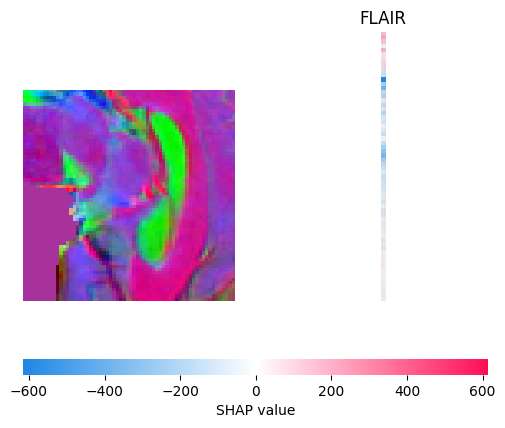

In [29]:
slice_idx = input_tensor.shape[2] // 2

# Preparar a imagem original (Background)
# O SHAP image_plot espera a imagem no formato [batch, H, W, channels]
img_to_plot = input_tensor[0, :, slice_idx, :, :].detach().cpu().numpy()
img_to_plot = np.transpose(img_to_plot, (1, 2, 0)) # Move canais para o fim
img_to_plot = np.expand_dims(img_to_plot, axis=0) # Adiciona dimensão de batch

# Preparar os SHAP values
# shap_values_unet[0] tem shape (1, 4, 128, 128, 128)
shap_to_plot = shap_values_unet[0][0, :, slice_idx, :, :]
shap_to_plot = np.transpose(shap_to_plot, (1, 2, 0)) # Move canais para o fim
shap_to_plot = np.expand_dims(shap_to_plot, axis=0) # Adiciona dimensão de batch

modalidades = np.array([["FLAIR", "T1", "T1ce", "T2"]])

shap.image_plot(shap_to_plot, img_to_plot, labels=modalidades, show=False)

file_name_imageplot = f"../reports/shap/shap_unet3d_{model_opt}_{patient_id}.png"
plt.savefig(file_name_imageplot, bbox_inches='tight', dpi=300)
print(f">> SHAP Image Plot salvo em: {file_name_imageplot}")

plt.show()
plt.close()

In [19]:
reset_gpu_context(['model_unet', 'explainer_unet', 'shap_values_unet'])

--- Iniciando limpeza de memória ---
Deletando variável: model_unet
Deletando variável: explainer_unet
Deletando variável: shap_values_unet
VRAM Alocada: 26.56MB
VRAM Reservada: 46.00MB
--- Ambiente pronto para nova amostragem ---


#### 2.2.2 SegResNet

In [ ]:
model_segresnet = SegResNet(
  in_channels=4,
  out_channels=4,
  init_filters=16,
  dropout_prob=0.2,
).to(device)

model_opt = "v0"
model_segresnet.load_state_dict(torch.load(f"../models/best_metric_model_SegResNet_{model_opt}.pth"))
model_segresnet.eval()

In [ ]:
# Queremos explicar a Classe 3 (Enhancing Tumor)
wrapped_model = SegmentationModelWrapper(model_segresnet, class_idx=3).to(device)

explainer_seg = shap.GradientExplainer(wrapped_model, background)

shap_values_seg = explainer_seg.shap_values(input_tensor, nsamples=50)

In [ ]:
slice_idx = input_tensor.shape[2] // 2
modalidades = ["FLAIR", "T1", "T1ce", "T2"]

img_slice = input_tensor[0, 0, slice_idx, :, :].detach().cpu().numpy()
img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Como usamos o wrapper para a Classe 3, o resultado está no índice 0
shap_data = shap_values_seg[0]

for i, mod in enumerate(modalidades):
    # s shape: (D, H, W) -> Pegamos o slice_idx
    s = shap_data[0, i, slice_idx, :, :]

    # Plotar a imagem original de fundo (com transparência)
    axes[i].imshow(img_slice, cmap="gray", alpha=0.3)

    # Plotar o SHAP (RdBu_r: Vermelho é positivo, Azul é negativo)
    vmax = np.abs(s).max() + 1e-8
    im = axes[i].imshow(s, cmap="RdBu_r", vmin=-vmax, vmax=vmax)

    axes[i].set_title(f"Contribuição: {mod}")
    axes[i].axis("off")
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.tight_layout()

file_name_overlay = f"../reports/shap/shap_overlay_segresnet_{model_opt}_{patient_id}.png"
plt.savefig(file_name_overlay, bbox_inches='tight', dpi=300)
print(f">> SHAP Overlay salvo em: {file_name_overlay}")

plt.show()
plt.close()

In [ ]:
slice_idx = input_tensor.shape[2] // 2

# Preparar a imagem original (Background)
# O SHAP image_plot espera a imagem no formato [batch, H, W, channels]
img_to_plot = input_tensor[0, :, slice_idx, :, :].detach().cpu().numpy()
img_to_plot = np.transpose(img_to_plot, (1, 2, 0)) # Move canais para o fim
img_to_plot = np.expand_dims(img_to_plot, axis=0) # Adiciona dimensão de batch

# Preparar os SHAP values
shap_to_plot = shap_values_seg[0][0, :, slice_idx, :, :]
shap_to_plot = np.transpose(shap_to_plot, (1, 2, 0)) # Move canais para o fim
shap_to_plot = np.expand_dims(shap_to_plot, axis=0) # Adiciona dimensão de batch

modalidades = np.array([["FLAIR", "T1", "T1ce", "T2"]])

shap.image_plot(shap_to_plot, img_to_plot, labels=modalidades, show=False)

file_name_imageplot = f"../reports/shap/shap_imageplot_segresnet_{model_opt}_{patient_id}.png"
plt.savefig(file_name_imageplot, bbox_inches='tight', dpi=300)
print(f">> SHAP Image Plot salvo em: {file_name_imageplot}")

plt.show()
plt.close()

In [ ]:
reset_gpu_context(['model_segresnet', 'explainer_seg', 'shap_values_seg'])

#### 2.2.3 Swin UNETR

In [ ]:
model_swin = SwinUNETR(
  in_channels=4,
  out_channels=4,
  feature_size=12,
  use_checkpoint=True,
).to(device)

model_swin.load_state_dict(torch.load("../models/best_metric_model_swin_unetr.pth"))
model_swin.eval()

In [ ]:
# Queremos explicar a Classe 3 (Enhancing Tumor)
wrapped_model = SegmentationModelWrapper(model_swin, class_idx=3).to(device)

explainer_swin = shap.GradientExplainer(wrapped_model, background)

shap_values_swin = explainer_swin.shap_values(input_tensor, nsamples=50)

In [ ]:
slice_idx = input_tensor.shape[2] // 2
modalidades = ["FLAIR", "T1", "T1ce", "T2"]

img_slice = input_tensor[0, 0, slice_idx, :, :].detach().cpu().numpy()
img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Como usamos o wrapper para a Classe 3, o resultado está no índice 0
shap_data = shap_values_swin[0]

for i, mod in enumerate(modalidades):
    # s shape: (D, H, W) -> Pegamos o slice_idx
    s = shap_data[0, i, slice_idx, :, :]

    # Plotar a imagem original de fundo (com transparência)
    axes[i].imshow(img_slice, cmap="gray", alpha=0.3)

    # Plotar o SHAP (RdBu_r: Vermelho é positivo, Azul é negativo)
    vmax = np.abs(s).max() + 1e-8
    im = axes[i].imshow(s, cmap="RdBu_r", vmin=-vmax, vmax=vmax)

    axes[i].set_title(f"Contribuição: {mod}")
    axes[i].axis("off")
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
slice_idx = input_tensor.shape[2] // 2

# Preparar a imagem original (Background)
# O SHAP image_plot espera a imagem no formato [batch, H, W, channels]
img_to_plot = input_tensor[0, :, slice_idx, :, :].detach().cpu().numpy()
img_to_plot = np.transpose(img_to_plot, (1, 2, 0)) # Move canais para o fim
img_to_plot = np.expand_dims(img_to_plot, axis=0) # Adiciona dimensão de batch

# Preparar os SHAP values
shap_to_plot = shap_values_swin[0][0, :, slice_idx, :, :]
shap_to_plot = np.transpose(shap_to_plot, (1, 2, 0)) # Move canais para o fim
shap_to_plot = np.expand_dims(shap_to_plot, axis=0) # Adiciona dimensão de batch

modalidades = np.array([["FLAIR", "T1", "T1ce", "T2"]])

shap.image_plot(shap_to_plot, img_to_plot, labels=modalidades)

In [ ]:
reset_gpu_context(['model_swin', 'explainer_swin', 'shap_values_swin'])